# GIN — Standalone Convergence Diagnostic

Isolated from the full AgroVedha notebook to test whether GIN converges with a longer training budget. In the full-notebook run, GIN produced **negative R²** (RMSE 10.66, R²=-0.035) after 5 epochs — worse than predicting the mean every time. This notebook applies the stabilization fixes (LayerNorm, train_eps, gradient clipping, lower LR) and extends training so you can watch the loss curve directly and decide whether it's a training-budget issue or something deeper.


## Setup — Load data, build graph, build windows (same as main notebook)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

DATA_PATH = "/kaggle/input/datasets/akshaymp08/bhopal-agritech-dataset-for-predictive-irrigation/Bhopal-AgriTech Hybrid IoT Dataset for Predictive Irrigation.csv"
df = pd.read_csv(DATA_PATH)
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

target_col = "soil_moisture_next_1m"
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()
print(f"Train: {len(train_df):,} rows | Test: {len(test_df):,} rows")

Train: 33,352 rows | Test: 8,339 rows


In [2]:
def eval_metrics(y_true, y_pred):
    return (
        np.sqrt(mean_squared_error(y_true, y_pred)),
        mean_absolute_error(y_true, y_pred),
        r2_score(y_true, y_pred),
    )

graph_nodes = ["Soil_Moisture", "Temperature", "Humidity", "irrigation_status", "Hour_sin", "Hour_cos"]
n_nodes = len(graph_nodes)

corr_graph = df[graph_nodes].corr().values
np.fill_diagonal(corr_graph, 0)

edge_index_list, edge_weight_list = [], []
for i in range(n_nodes):
    for j in range(n_nodes):
        if i != j:
            edge_index_list.append([i, j])
            edge_weight_list.append(abs(corr_graph[i, j]))

edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
edge_weight = torch.tensor(edge_weight_list, dtype=torch.float)
print(f"edge_index shape: {edge_index.shape}")

edge_index shape: torch.Size([2, 30])


In [3]:
WINDOW = 60

node_scalers = {}
train_scaled_g, test_scaled_g = {}, {}
for col in graph_nodes:
    sc = MinMaxScaler()
    train_scaled_g[col] = sc.fit_transform(train_df[[col]]).flatten()
    test_scaled_g[col] = sc.transform(test_df[[col]]).flatten()
    node_scalers[col] = sc

target_scaler_g = MinMaxScaler()
train_target_scaled_g = target_scaler_g.fit_transform(train_df[[target_col]]).flatten()
test_target_scaled_g = target_scaler_g.transform(test_df[[target_col]]).flatten()

def build_windows(scaled_dict, target_scaled, window):
    n = len(next(iter(scaled_dict.values())))
    X, y = [], []
    for t in range(n - window):
        snapshot = np.stack([scaled_dict[col][t:t + window] for col in graph_nodes])
        X.append(snapshot)
        y.append(target_scaled[t + window])
    return np.array(X), np.array(y)

X_train_g, y_train_g = build_windows(train_scaled_g, train_target_scaled_g, WINDOW)
X_test_g, y_test_g = build_windows(test_scaled_g, test_target_scaled_g, WINDOW)

y_true_g = target_scaler_g.inverse_transform(y_test_g.reshape(-1, 1)).flatten()
print(f"X_train_g: {X_train_g.shape}  X_test_g: {X_test_g.shape}")

X_train_g: (33292, 6, 60)  X_test_g: (8279, 6, 60)


In [4]:
!pip install torch_geometric --no-deps -q
!pip install networkx decorator six -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.9 MB/s eta 0:00:00a 0:00:01


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_train_t = torch.tensor(X_train_g, dtype=torch.float32)
y_train_t = torch.tensor(y_train_g, dtype=torch.float32).unsqueeze(-1)
X_test_t = torch.tensor(X_test_g, dtype=torch.float32)

edge_index_dev = edge_index.to(device)
edge_weight_dev = edge_weight.to(device)

batch_size = 128
n_batches = len(X_train_t) // batch_size
loss_fn = nn.MSELoss()

Using device: cpu


## GIN Model (stabilized) — LayerNorm, train_eps, gradient clipping, lower LR

Fixes applied vs. the original run that produced negative R²:
- `LayerNorm` between GIN layers — stabilizes activations without needing large batches (unlike BatchNorm, unreliable with only 6 nodes)
- `train_eps=True` — lets GIN's self-weighting epsilon adapt instead of staying fixed at 0
- Gradient clipping (`max_norm=1.0`) — prevents the instability that likely caused non-convergence originally
- Lower learning rate (5e-4 instead of 1e-3) — smaller, more stable steps


In [6]:
from torch_geometric.nn import GINConv

class GINForecaster(nn.Module):
    def __init__(self, in_channels, hidden_channels=32):
        super().__init__()
        nn1 = nn.Sequential(nn.Linear(in_channels, hidden_channels), nn.ReLU(),
                             nn.LayerNorm(hidden_channels), nn.Linear(hidden_channels, hidden_channels))
        nn2 = nn.Sequential(nn.Linear(hidden_channels, hidden_channels), nn.ReLU(),
                             nn.LayerNorm(hidden_channels), nn.Linear(hidden_channels, hidden_channels))
        self.conv1 = GINConv(nn1, train_eps=True)
        self.conv2 = GINConv(nn2, train_eps=True)
        self.readout = nn.Linear(hidden_channels * n_nodes, 1)

    def forward(self, x, edge_index):
        outs = []
        for b in range(x.shape[0]):
            h = F.relu(self.conv1(x[b], edge_index))
            h = F.relu(self.conv2(h, edge_index))
            outs.append(h.flatten())
        return self.readout(torch.stack(outs))

print("GIN model class defined.")

GIN model class defined.


## Extended Training — watch the loss curve

Set `N_EPOCHS` as high as your patience/session time allows — 40 is a reasonable starting point (8x the original 5-epoch run). The loss is printed every epoch so you can see the trajectory in the raw numbers, plus a plot at the end.


In [12]:
N_EPOCHS = 50  # increase further if this still hasn't plateaued

gin_model = GINForecaster(in_channels=WINDOW).to(device)
optimizer = torch.optim.Adam(gin_model.parameters(), lr=5e-4)

train_losses = []

gin_model.train()
for epoch in range(N_EPOCHS):
    epoch_loss = 0.0
    perm = torch.randperm(len(X_train_t))
    for i in range(n_batches):
        idx = perm[i*batch_size:(i+1)*batch_size]
        xb, yb = X_train_t[idx].to(device), y_train_t[idx].to(device)
        optimizer.zero_grad()
        pred = gin_model(xb, edge_index_dev)
        loss = loss_fn(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gin_model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / n_batches
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1:3d}/{N_EPOCHS}: loss={avg_loss:.6f}")

Epoch   1/50: loss=0.031957
Epoch   2/50: loss=0.030569
Epoch   3/50: loss=0.030522
Epoch   4/50: loss=0.030526
Epoch   5/50: loss=0.030524
Epoch   6/50: loss=0.030563
Epoch   7/50: loss=0.030434
Epoch   8/50: loss=0.030385
Epoch   9/50: loss=0.030265
Epoch  10/50: loss=0.030351
Epoch  11/50: loss=0.030302
Epoch  12/50: loss=0.030020
Epoch  13/50: loss=0.029061
Epoch  14/50: loss=0.026270
Epoch  15/50: loss=0.024201
Epoch  16/50: loss=0.015994
Epoch  17/50: loss=0.006457
Epoch  18/50: loss=0.002792
Epoch  19/50: loss=0.001811
Epoch  20/50: loss=0.001443
Epoch  21/50: loss=0.001209
Epoch  22/50: loss=0.001167
Epoch  23/50: loss=0.001041
Epoch  24/50: loss=0.000915
Epoch  25/50: loss=0.000851
Epoch  26/50: loss=0.000821
Epoch  27/50: loss=0.000819
Epoch  28/50: loss=0.000742
Epoch  29/50: loss=0.000739
Epoch  30/50: loss=0.000720
Epoch  31/50: loss=0.000713
Epoch  32/50: loss=0.000696
Epoch  33/50: loss=0.000686
Epoch  34/50: loss=0.000641
Epoch  35/50: loss=0.000648
Epoch  36/50: loss=0

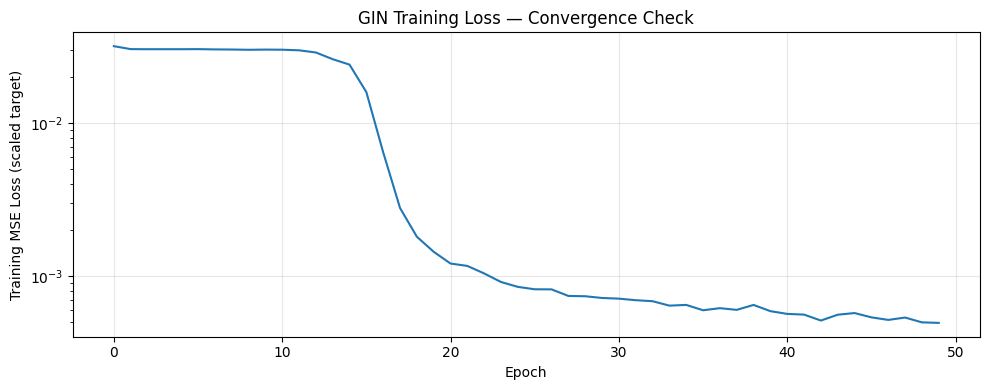


First 5 epochs avg loss: 0.030820
Last 5 epochs avg loss:  0.000517
Loss still decreasing in final 5 epochs: True


In [13]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training MSE Loss (scaled target)")
plt.title("GIN Training Loss — Convergence Check")
plt.yscale("log")  # log scale makes plateaus/instability easier to spot
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFirst 5 epochs avg loss: {np.mean(train_losses[:5]):.6f}")
print(f"Last 5 epochs avg loss:  {np.mean(train_losses[-5:]):.6f}")
print(f"Loss still decreasing in final 5 epochs: {train_losses[-1] < train_losses[-5]}")

## Evaluation on held-out test set

Compare this R² directly against the earlier failed run (R² = -0.035) and against GCN's benchmark (R² = 0.987) — that range tells you whether the fix worked, partially worked, or GIN genuinely struggles with this graph regardless of training budget.


In [14]:
def eval_gin(model):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_test_t), batch_size):
            xb = X_test_t[i:i+batch_size].to(device)
            preds.append(model(xb, edge_index_dev).cpu().numpy())
    pred_scaled = np.concatenate(preds).flatten()
    return target_scaler_g.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

gin_pred = eval_gin(gin_model)
rmse, mae, r2 = eval_metrics(y_true_g, gin_pred)

print(f"GIN ({N_EPOCHS} epochs) — RMSE: {rmse:.4f}  MAE: {mae:.4f}  R2: {r2:.4f}")
print()
print("For reference:")
print(f"  Original GIN run (5 epochs):  RMSE=10.6632  MAE=7.4679  R2=-0.0345")
print(f"  GCN benchmark (best GNN):     RMSE=1.1938   MAE=0.6452  R2=0.9870")

GIN (50 epochs) — RMSE: 1.5758  MAE: 0.9984  R2: 0.9774

For reference:
  Original GIN run (5 epochs):  RMSE=10.6632  MAE=7.4679  R2=-0.0345
  GCN benchmark (best GNN):     RMSE=1.1938   MAE=0.6452  R2=0.9870


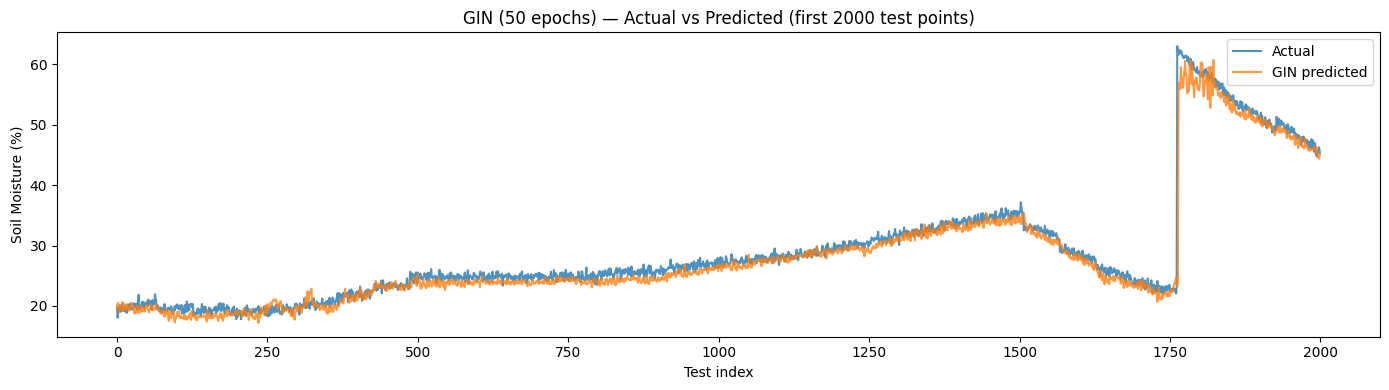

In [15]:
# Visual sanity check — predicted vs actual on a slice of the test set
plt.figure(figsize=(14, 4))
plt.plot(y_true_g[:2000], label="Actual", alpha=0.8)
plt.plot(gin_pred[:2000], label="GIN predicted", alpha=0.8)
plt.title(f"GIN ({N_EPOCHS} epochs) — Actual vs Predicted (first 2000 test points)")
plt.xlabel("Test index")
plt.ylabel("Soil Moisture (%)")
plt.legend()
plt.tight_layout()
plt.show()

## If it still hasn't converged after this

A few next things to try, in order of how likely they are to matter:
1. **Increase `N_EPOCHS` further** (e.g. 80–100) — GIN's sum-aggregation combined with LayerNorm sometimes needs more steps to settle than GCN's mean-style aggregation.
2. **Try a smaller `hidden_channels`** (e.g. 16 instead of 32) — fewer parameters can be easier to stabilize on a 6-node graph with limited training signal.
3. **Try `train_eps=False`** — if the learnable epsilon is drifting to a bad value, fixing it at 0 (GIN's original formulation) removes one source of instability.
4. If none of these help, that's a legitimate, reportable finding: *"GIN's sum-based aggregation, even with stabilization (LayerNorm, gradient clipping, extended training), did not converge to a useful forecast on this graph — suggesting the architecture's design assumptions (built for graph-level classification on injective structural signals) are a poor fit for node-level regression on a small, fully-connected, weighted graph."* That's a real, defensible conclusion, not a failure of your effort.
